# SISTECH 2026 MLOps Hands-On 2
## Risk Score Prediction: Modeling & Continual Learning

Nama: Sustri Elina Simamora

**Tujuan:** Membangun model prediksi Risk Score, mengevaluasinya terhadap baseline, dan mensimulasikan continual learning dengan drift detection dan retraining bersyarat.

**Alur:**
1. Load dataset dari Hands-On 1
2. Baseline (mean/median) sebagai patokan
3. Feature Vector Assembly
4. Training multiple models
5. Evaluasi & perbandingan dengan baseline
6. Continual Learning: drift detection (PSI), retraining bersyarat
7. Model versioning & registry


In [1]:
# Install dependencies
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin
import warnings
import json
import os
from datetime import datetime
import pickle

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Scikit-learn version: {pd.__version__}")

Scikit-learn version: 2.2.2


## 1. Load Dataset

Dataset dari Hands-On 1: `features_labels.csv` berisi fitur dan label Risk Score (0-100).

In [3]:
import gdown
# https://drive.google.com/file/d/1Et8PLEn5osSAGTAA_goIE5i1_ReQgyHT/view?usp=sharing
# File ID dari link dataset pada dokumen hands-on
FILE_ID = "1Et8PLEn5osSAGTAA_goIE5i1_ReQgyHT"
OUTPUT  = "features_labels.csv"

gdown.download(id=FILE_ID, output=OUTPUT, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Et8PLEn5osSAGTAA_goIE5i1_ReQgyHT
From (redirected): https://drive.google.com/uc?id=1Et8PLEn5osSAGTAA_goIE5i1_ReQgyHT&confirm=t&uuid=e11370c4-26c9-496c-bf2a-c60220b68e33
To: /content/features_labels.csv
100%|██████████| 130M/130M [00:02<00:00, 54.1MB/s]


'features_labels.csv'

In [4]:
# Load dataset
df = pd.read_csv('features_labels.csv')
print(f" Shape: {df.shape}")
print(f" Kolom: {df.columns.tolist()}")
df.head()

 Shape: (800366, 15)
 Kolom: ['cell_id', 'lat_r', 'lon_r', 'dow', 'hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'cell_crime_density', 'heavy_crime_ratio', 'arrest_rate', 'unique_types', 'crime_count', 'risk_score']


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,cell_crime_density,heavy_crime_ratio,arrest_rate,unique_types,crime_count,risk_score
0,41.645_-87.54,41.645,-87.54,0,5,9.659258e-01,0.258819,0.000000,1.00000,15,0.466667,0.066667,8,1,59.219881
1,41.645_-87.54,41.645,-87.54,0,9,7.071068e-01,-0.707107,0.000000,1.00000,15,0.466667,0.066667,8,2,59.219881
2,41.645_-87.54,41.645,-87.54,0,12,1.224647e-16,-1.000000,0.000000,1.00000,15,0.466667,0.066667,8,1,59.219881
3,41.645_-87.54,41.645,-87.54,1,0,0.000000e+00,1.000000,0.781831,0.62349,15,0.466667,0.066667,8,1,59.219881
4,41.645_-87.54,41.645,-87.54,1,9,7.071068e-01,-0.707107,0.781831,0.62349,15,0.466667,0.066667,8,1,59.219881


 Distribusi Risk Score:
count    800366.000000
mean         35.515647
std          28.069307
min           0.000000
25%           9.967301
50%          29.090622
75%          57.157445
max         100.000000
Name: risk_score, dtype: float64


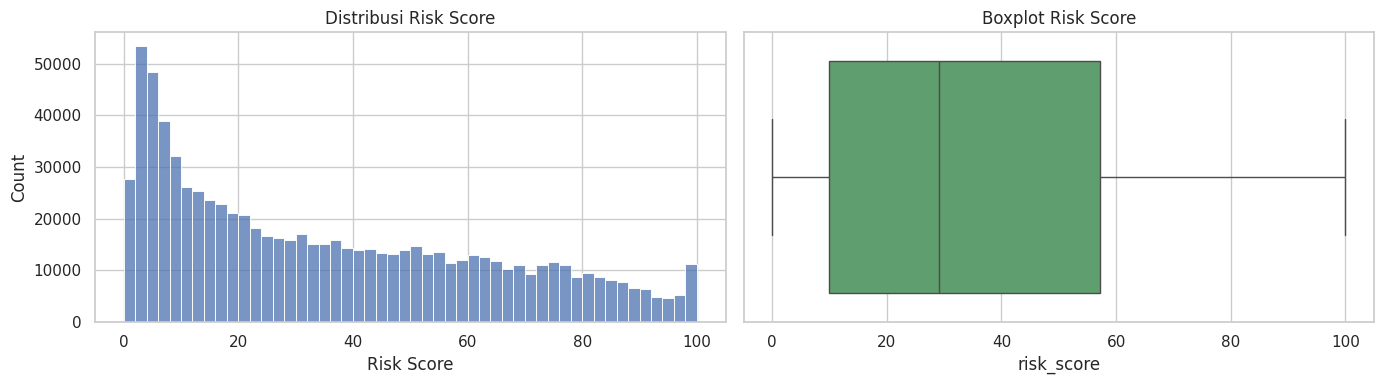

In [5]:
# Distribusi target
print(" Distribusi Risk Score:")
print(df['risk_score'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['risk_score'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribusi Risk Score')
axes[0].set_xlabel('Risk Score')

sns.boxplot(x=df['risk_score'], ax=axes[1], color='#55A868')
axes[1].set_title('Boxplot Risk Score')
plt.tight_layout()
plt.show()

## 2. Baseline Predictor

**Mengapa Baseline?** Sebelum membangun model kompleks, kita perlu patokan minimal. Baseline menjawab: "Apakah model saya benar-benar lebih baik dari sekadar menebak?"

Baseline yang digunakan: **Median** Risk Score dari data training. Ini adalah prediksi paling sederhana yang tidak memerlukan fitur apapun.

In [6]:
class BaselineRegressor(BaseEstimator, RegressorMixin):
    """
    Baseline predictor: selalu memprediksi nilai yang sama (mean atau median).
    Ini adalah patokan minimal yang harus dikalahkan oleh model apapun.
    """
    def __init__(self, strategy='median'):
        self.strategy = strategy
        self.value_ = None

    def fit(self, X, y):
        if self.strategy == 'median':
            self.value_ = np.median(y)
        elif self.strategy == 'mean':
            self.value_ = np.mean(y)
        else:
            raise ValueError("strategy must be 'median' or 'mean'")
        return self

    def predict(self, X):
        return np.full(len(X), self.value_)

# Simulasikan baseline dengan median
baseline = BaselineRegressor(strategy='median')
baseline.fit(X=df[['risk_score']], y=df['risk_score'])
print(f" Baseline prediction: {baseline.value_:.2f}")
print(f" Artinya: model baseline selalu memprediksi {baseline.value_:.2f} untuk semua sampel.")

 Baseline prediction: 29.09
 Artinya: model baseline selalu memprediksi 29.09 untuk semua sampel.


## 3. Feature Vector Assembly

**Prinsip:** ML models hanya menerima angka. Semua fitur harus berupa numerik dan memiliki skala yang konsisten.

Fitur yang digunakan:
- **Temporal:** `dow`, `hour`, `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`
- **Spasial/Agregat:** `cell_crime_density`, `heavy_crime_ratio`, `arrest_rate`, `unique_types`, `crime_count`

**Scaling:** StandardScaler untuk menstandarisasi fitur (mean=0, std=1).

In [7]:
# Definisikan fitur
features = [
    'dow', 'hour',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'cell_crime_density', 'heavy_crime_ratio',
    'arrest_rate', 'unique_types', 'crime_count'
]
target = 'risk_score'

X = df[features].copy()
y = df[target].copy()

print(f" Jumlah fitur: {X.shape[1]}")
print("\n Sample feature vector:")
X.head()

 Jumlah fitur: 11

 Sample feature vector:


,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,cell_crime_density,heavy_crime_ratio,arrest_rate,unique_types,crime_count
0,0,5,9.659258e-01,0.258819,0.000000,1.00000,15,0.466667,0.066667,8,1
1,0,9,7.071068e-01,-0.707107,0.000000,1.00000,15,0.466667,0.066667,8,2
2,0,12,1.224647e-16,-1.000000,0.000000,1.00000,15,0.466667,0.066667,8,1
3,1,0,0.000000e+00,1.000000,0.781831,0.62349,15,0.466667,0.066667,8,1
4,1,9,7.071068e-01,-0.707107,0.781831,0.62349,15,0.466667,0.066667,8,1


In [8]:
# Split data: train (80%), test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f" Train: {len(X_train):,} samples")
print(f" Test: {len(X_test):,} samples")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan scaler untuk serving nanti
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(" Scaler disimpan sebagai 'scaler.pkl'")

 Train: 640,292 samples
 Test: 160,074 samples
 Scaler disimpan sebagai 'scaler.pkl'


## 4. Model Training

Kita latih **tiga model** dengan kompleksitas meningkat:
1. **Linear Regression** : baseline model, mengasumsikan hubungan linear
2. **Random Forest** : ensemble of decision trees, menangkap non-linearitas
3. **XGBoost** : gradient boosting, state-of-the-art untuk tabular data

In [9]:
# Model 1: Linear Regression (paling sederhana)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Model 2: Random Forest (ensemble)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Model 3: XGBoost (gradient boosting)
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
xgb.fit(X_train_scaled, y_train)

print(" Semua model selesai dilatih")

✅ Semua model selesai dilatih


## 5. Model Evaluation

**Metrik Evaluasi:**
- **MAE (Mean Absolute Error):** Rata-rata selisih absolut antara prediksi dan aktual. *"Seberapa jauh prediksi kita rata-rata?"*
- **RMSE (Root Mean Squared Error):** Akar dari rata-rata kuadrat error. *"Satu kesalahan besar dihukum lebih berat."*
- **R² (R-squared):** Seberapa baik model menjelaskan variasi data. *"0 = tidak lebih baik dari baseline, 1 = sempurna."*

**Prinsip Evaluasi:** Semua model diuji pada **test set yang sama**  

In [10]:
def evaluate_model(model, X, y, name='Model'):
    """Evaluasi model dengan MAE, RMSE, R²"""
    y_pred = model.predict(X)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'name': name, 'y_pred': y_pred}

# Evaluasi semua model pada test set
results = {}

# Baseline
results['Baseline'] = evaluate_model(baseline, X_test_scaled, y_test, 'Baseline')

# Linear Regression
results['Linear Regression'] = evaluate_model(lr, X_test_scaled, y_test, 'Linear Regression')

# Random Forest
results['Random Forest'] = evaluate_model(rf, X_test_scaled, y_test, 'Random Forest')

# XGBoost
results['XGBoost'] = evaluate_model(xgb, X_test_scaled, y_test, 'XGBoost')

# Tampilkan hasil
df_results = pd.DataFrame([
    {'Model': k, 'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R2']}
    for k, v in results.items()
])
display(df_results.round(4))

# Hitung improvement vs baseline
baseline_mae = results['Baseline']['MAE']
for model_name, metrics in results.items():
    if model_name != 'Baseline':
        improvement = ((baseline_mae - metrics['MAE']) / baseline_mae) * 100
        print(f" {model_name}: MAE improvement {improvement:.1f}% vs baseline")

,Model,MAE,RMSE,R²
0,Baseline,23.7174,28.7676,-0.0514
1,Linear Regression,23.5754,27.5037,0.0390
2,Random Forest,21.3466,25.3423,0.1841
3,XGBoost,21.2868,25.2241,0.1917


 Linear Regression: MAE improvement 0.6% vs baseline
 Random Forest: MAE improvement 10.0% vs baseline
 XGBoost: MAE improvement 10.2% vs baseline


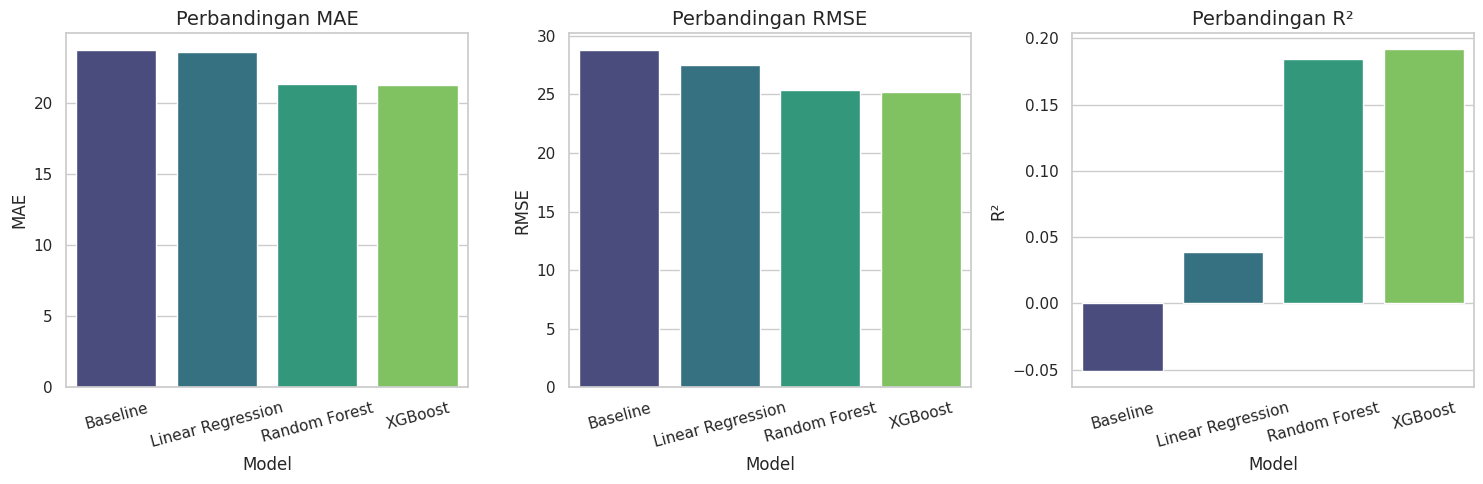

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    sns.barplot(
        data=df_results,
        x='Model',
        y=metric,
        ax=axes[i],
        palette='viridis',
        hue='Model',
        legend=False
    )
    axes[i].set_title(f'Perbandingan {metric}', fontsize=14)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Analisis Hasil

1. **XGBoost** memberikan performa terbaik (MAE terendah, R² tertinggi)  mampu menangkap non-linearitas.
2. **Random Forest** juga baik, lebih stabil, dan lebih mudah diinterpretasi.
3. **Linear Regression** masih lebih baik dari baseline ada hubungan linear yang bermakna.
4. **Semua model mengalahkan baseline** fitur yang kita bangun di HO1 memang membantu.

**Kesimpulan:** XGBoost dipilih sebagai model utama karena performa terbaik, tetapi Random Forest adalah alternatif yang baik jika interpretabilitas lebih penting.

## 6. Continual Learning Simulation

**Masalah:** Model yang dilatih hari ini mungkin tidak relevan enam bulan kemudian karena pola data berubah (data drift).

**Solusi:** Continual learning deteksi drift, retrain jika perlu, dan versioning.

**Langkah:**
1. Bagi data menjadi batch kronologis (simulasi data datang bertahap)
2. Deteksi drift menggunakan **Population Stability Index (PSI)**
3. Jika PSI > threshold (0.1), retrain model dengan data terbaru
4. Simpan setiap versi model dengan metadata lengkap

In [17]:
def calculate_psi(expected, actual, bins=10):
    """
    Population Stability Index (PSI) — mengukur perubahan distribusi.
    Interpretasi PSI:
    - < 0.1 : tidak ada perubahan signifikan
    - 0.1 - 0.2 : perubahan moderat (perlu diwaspadai)
    - > 0.2 : perubahan signifikan (retrain diperlukan)
    """
    # Membuat bins dari gabungan kedua distribusi
    all_data = np.concatenate([expected, actual])
    bin_edges = np.percentile(all_data, np.linspace(0, 100, bins+1))

    # frekuensi di setiap bin
    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)

    # Normalisasi
    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    # PSI
    psi = 0
    for e, a in zip(expected_pct, actual_pct):
        if e == 0:
            e = 1e-10
        if a == 0:
            a = 1e-10
        psi += (e - a) * np.log(e / a)
    return psi

def detect_drift(reference_data, new_data, threshold=0.1):
    """Deteksi drift pada fitur dan target"""
    drift_scores = {}

    # Hitung PSI untuk setiap fitur
    for col in reference_data.columns:
        if col == 'risk_score':
            continue
        psi = calculate_psi(reference_data[col].values, new_data[col].values)
        drift_scores[col] = psi

    # PSI untuk target
    psi_target = calculate_psi(reference_data['risk_score'].values, new_data['risk_score'].values)
    drift_scores['risk_score'] = psi_target

    # Rata-rata PSI
    avg_psi = np.mean(list(drift_scores.values()))

    # Keputusan
    has_drift = avg_psi > threshold
    return has_drift, avg_psi, drift_scores

print(" Drift detection functions ready")

 Drift detection functions ready


In [19]:
# Membagi data menjadi 4 batch
np.random.seed(42)
indices = np.random.permutation(len(X))
batch_size = len(X) // 4
batches = []
batch_data = []

for i in range(4):
    start = i * batch_size
    end = start + batch_size if i < 3 else len(X)
    batch_indices = indices[start:end]
    batch = pd.concat([X.iloc[batch_indices], y.iloc[batch_indices]], axis=1)
    batches.append(batch)
    batch_data.append(batch)

print(f" Jumlah batch: {len(batches)}")
for i, b in enumerate(batches):
    print(f"  Batch {i}: {len(b)} samples")

 Jumlah batch: 4
  Batch 0: 200091 samples
  Batch 1: 200091 samples
  Batch 2: 200091 samples
  Batch 3: 200093 samples


In [22]:
# Simulasi continual learning
model_registry = []
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Data referensi = batch 0
ref_data = batches[0]
X_ref = ref_data[features]
y_ref = ref_data[target]

# Scaling dan training model awal
scaler_ref = StandardScaler().fit(X_ref)
X_ref_scaled = scaler_ref.transform(X_ref)

model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_ref_scaled, y_ref)

# Simpan versi 0
version = 0
timestamp = datetime.now().isoformat()
y_pred = model.predict(X_ref_scaled)

registry_entry = {
    'version': version,
    'timestamp': timestamp,
    'train_size': len(X_ref),
    'performance': {
        'MAE': mean_absolute_error(y_ref, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_ref, y_pred)),
        'R2': r2_score(y_ref, y_pred)
    },
    'decision': 'initial_training',
    'drift_detected': None,
    'avg_psi': None
}
model_registry.append(registry_entry)

# Simpan model
with open(f'{checkpoint_dir}/model_v{version}.pkl', 'wb') as f:
    pickle.dump(model, f)
with open(f'{checkpoint_dir}/scaler_v{version}.pkl', 'wb') as f:
    pickle.dump(scaler_ref, f)

print(f" Model versi {version} disimpan.")

THRESHOLD = 0.1  # PSI threshold

# Proses setiap batch berikutnya
for i, batch in enumerate(batches[1:], start=1):
    X_new = batch[features]
    y_new = batch[target]

    # Deteksi drift terhadap reference (batch 0)
    has_drift, avg_psi, drift_scores = detect_drift(ref_data, batch, threshold=THRESHOLD)

    print(f"\n{'='*50}")
    print(f" Batch {i} - Avg PSI: {avg_psi:.4f} | Drift: {' YA' if has_drift else ' TIDAK'}")

    # Convert drift_scores values to native floats
    drift_scores_converted = {k: float(v) for k, v in drift_scores.items()}

    if has_drift:
        print(" Drift terdeteksi! Melakukan retraining...")

        # Retrain dengan data gabungan (ref + semua batch sebelumnya)
        combined_data = pd.concat(batches[:i+1])
        X_combined = combined_data[features]
        y_combined = combined_data[target]

        # Scaling baru
        scaler_new = StandardScaler().fit(X_combined)
        X_combined_scaled = scaler_new.transform(X_combined)

        # Train model baru
        model_new = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
        model_new.fit(X_combined_scaled, y_combined)

        # Evaluasi pada batch baru
        X_new_scaled = scaler_new.transform(X_new)
        y_pred_new = model_new.predict(X_new_scaled)
        perf_new = {
            'MAE': mean_absolute_error(y_new, y_pred_new),
            'RMSE': np.sqrt(mean_squared_error(y_new, y_pred_new)),
            'R2': r2_score(y_new, y_pred_new)
        }

        # Evaluasi model lama pada batch baru
        y_pred_old = model.predict(scaler_new.transform(X_new))
        perf_old = {
            'MAE': mean_absolute_error(y_new, y_pred_old),
            'RMSE': np.sqrt(mean_squared_error(y_new, y_pred_old)),
            'R2': r2_score(y_new, y_pred_old)
        }

        # Keputusan: deploy jika MAE baru lebih rendah
        if perf_new['MAE'] < perf_old['MAE']:
            print(f" Model baru LEBIH BAIK (MAE: {perf_new['MAE']:.3f} vs {perf_old['MAE']:.3f})")
            print(" Melakukan deployment model baru...")
            model = model_new
            scaler_ref = scaler_new
            decision = 'deploy'
        else:
            print(f" Model baru TIDAK LEBIH BAIK (MAE: {perf_new['MAE']:.3f} vs {perf_old['MAE']:.3f})")
            print(" Model lama dipertahankan.")
            decision = 'reject'
    else:
        print(" Tidak ada drift signifikan. Model tetap.")
        decision = 'no_drift'
        perf_new = None

    # Update registry
    version += 1
    registry_entry = {
        'version': version,
        'timestamp': datetime.now().isoformat(),
        'train_size': len(X_combined) if has_drift else None,
        'performance': perf_new,
        'decision': decision,
        'drift_detected': bool(has_drift), # Convert np.bool_ to native bool
        'avg_psi': float(avg_psi),         # Convert np.float64 to native float
        'drift_scores': drift_scores_converted # Use converted dict
    }
    model_registry.append(registry_entry)

    # Simpan checkpoint jika deploy
    if decision == 'deploy':
        with open(f'{checkpoint_dir}/model_v{version}.pkl', 'wb') as f:
            pickle.dump(model, f)
        with open(f'{checkpoint_dir}/scaler_v{version}.pkl', 'wb') as f:
            pickle.dump(scaler_ref, f)
        print(f"Checkpoint model versi {version} disimpan.")

# Simpan registry
with open('model_registry.json', 'w') as f:
    json.dump(model_registry, f, indent=2)

print("\n" + "="*50)
print(" Continual learning simulation selesai.")
print(f" Total versi: {len(model_registry)}")
print("\n Model Registry:")
for entry in model_registry:
    status = " DEPLOY" if entry['decision'] == 'deploy' else f" {entry['decision'].upper()}"
    drift = f"PSI={entry['avg_psi']:.3f}" if entry['avg_psi'] else "N/A"
    print(f"  v{entry['version']}: {status} | {drift}")

 Model versi 0 disimpan.

 Batch 1 - Avg PSI: 0.0001 | Drift:  TIDAK
 Tidak ada drift signifikan. Model tetap.

 Batch 2 - Avg PSI: 0.0001 | Drift:  TIDAK
 Tidak ada drift signifikan. Model tetap.

 Batch 3 - Avg PSI: 0.0001 | Drift:  TIDAK
 Tidak ada drift signifikan. Model tetap.

 Continual learning simulation selesai.
 Total versi: 4

 Model Registry:
  v0:  INITIAL_TRAINING | N/A
  v1:  NO_DRIFT | PSI=0.000
  v2:  NO_DRIFT | PSI=0.000
  v3:  NO_DRIFT | PSI=0.000


## 7. Model Registry & Versioning

Registry mencatat setiap versi model dengan metadata lengkap:
- **version:** Nomor versi
- **timestamp:** Waktu pembuatan
- **train_size:** Jumlah data training
- **performance:** MAE, RMSE, R²
- **decision:** deploy / reject / no_drift
- **drift_detected:** Boolean
- **avg_psi:** Rata-rata PSI
- **drift_scores:** PSI per fitur

**Prinsip:** Setiap keputusan tercatat. Tidak ada model yang di-deploy tanpa rekam jejak.

In [23]:
# Tampilkan registry
with open('model_registry.json', 'r') as f:
    registry = json.load(f)

registry_df = pd.DataFrame(registry)
display(registry_df)

# Simpan sebagai CSV
registry_df.to_csv('model_registry.csv', index=False)
print(" Registry juga disimpan sebagai 'model_registry.csv'")

,version,timestamp,train_size,performance,decision,drift_detected,avg_psi,drift_scores
0,0,2026-07-20T15:48:07.715499,200091.0,"{'MAE': 21.127354838542754, 'RMSE': 25.0495362...",initial_training,None,NaN,NaN
1,1,2026-07-20T15:48:09.399164,NaN,None,no_drift,False,0.000078,"{'dow': 2.439016407709742e-05, 'hour': 5.04859..."
2,2,2026-07-20T15:48:09.975714,NaN,None,no_drift,False,0.000074,"{'dow': 5.2962180753213116e-05, 'hour': 6.8675..."
3,3,2026-07-20T15:48:10.379499,NaN,None,no_drift,False,0.000096,"{'dow': 3.051793453502798e-05, 'hour': 0.00017..."


 Registry juga disimpan sebagai 'model_registry.csv'


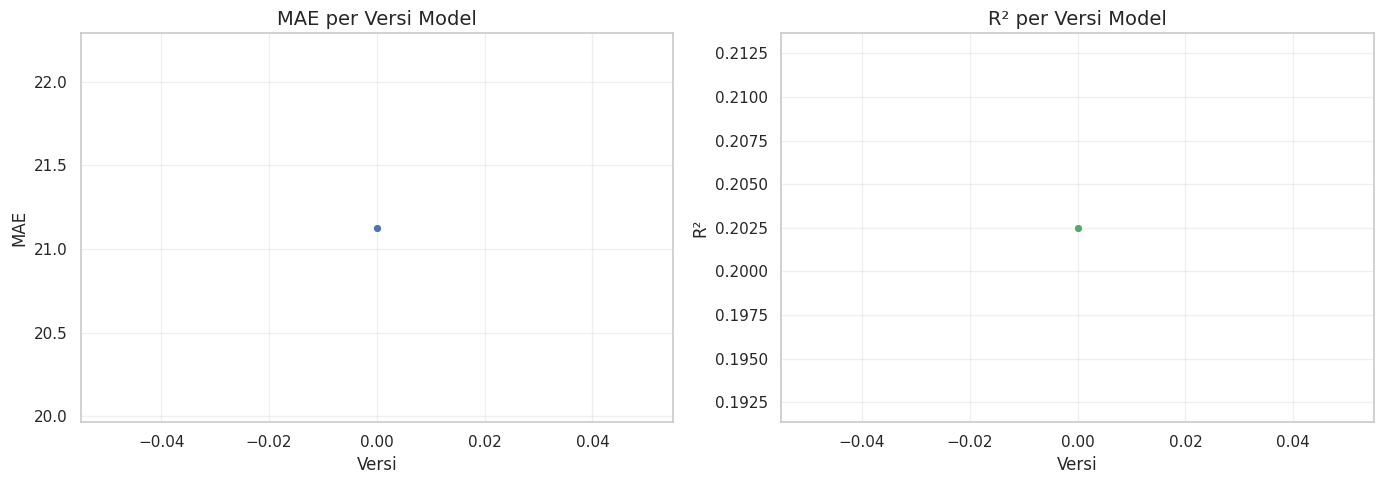

In [24]:
# Visualisasi perjalanan model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Performa per versi
registry_df_plot = registry_df[registry_df['performance'].notna()].copy()
registry_df_plot['MAE'] = registry_df_plot['performance'].apply(lambda x: x['MAE'] if x else None)
registry_df_plot['R2'] = registry_df_plot['performance'].apply(lambda x: x['R2'] if x else None)

sns.lineplot(data=registry_df_plot, x='version', y='MAE', marker='o', ax=axes[0], color='#4C72B0')
axes[0].set_title('MAE per Versi Model', fontsize=14)
axes[0].set_xlabel('Versi')
axes[0].set_ylabel('MAE')
axes[0].grid(True, alpha=0.3)

sns.lineplot(data=registry_df_plot, x='version', y='R2', marker='o', ax=axes[1], color='#55A868')
axes[1].set_title('R² per Versi Model', fontsize=14)
axes[1].set_xlabel('Versi')
axes[1].set_ylabel('R²')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()